# Attack day model training

In [18]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
from pathlib import Path


PROJECT_ROOT = Path("/content/drive/MyDrive/master-thesis").resolve()

SRC_PATH = PROJECT_ROOT / "src"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

os.chdir(PROJECT_ROOT)

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, cross_val_score

from notebooks.targeted_experiment_utils import (
    ATSSetup,
    TARGET_SIGNALS,
    candidate_attack_days
)

from scr.attack_day_model.create_data import create_attack_event_log
from scr.attack_day_model.preprocessing import prepare_attack_day_dataset, feature_correlation_analysis, chronological_train_test_split, TECHNICAL_FEATURE_COLUMNS, NON_FEATURE_COLUMNS
from scr.attack_day_model.model import build_model, evaluate, find_best_threshold, load_X, load_y, predict, save_model, load_model, feature_importance, ImbalanceStrategy

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_PATH:", SRC_PATH)
print("Current dir:", Path.cwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/master-thesis
SRC_PATH: /content/drive/MyDrive/master-thesis/src
Current dir: /content/drive/MyDrive/master-thesis


In [2]:
MODEL_FOLDERS = {
    "LSTM": NOTEBOOK_DIR / "models/LSTM_13_years",
    "LSTM3y": NOTEBOOK_DIR / "models/LSTM_3_years",
    "LSTM_cumulative": NOTEBOOK_DIR / "models/LSTM_cumulative",
    "LSTM_rolling": NOTEBOOK_DIR / "models/LSTM_rolling",
    "transformer": NOTEBOOK_DIR / "models/transformer",
}

ATTACK_MODEL_FOLDER = NOTEBOOK_DIR / "models/attack_day"

DATA_FOLDER = PROJECT_ROOT / "data/validation_time"

DATA_START       = "2013-01-01"
VALIDATION_START = "2021-01-01"
VALIDATION_END   = "2023-10-23"
ATTACK_START     = "2014-01-01"
ATTACK_END       = "2026-06-01"
QUARTERLY_MONTHS          = 3
EVALUATION_WINDOW_DAYS    = 20

TRAIN_MODE_BY_SETUP = {
    "LSTM_rolling_ALL_MA":      "rolling",
    "LSTM_rolling_All_BB":      "rolling",
    "LSTM_rolling_All_ROC":     "rolling",
    "LSTM_cumulative_All_BB":   "cumulative",
    "LSTM3y_All_BB":            "cumulative",
    "LSTM13y_All_BB":           "cumulative",
}

EXPERIMENT_NAME  = "attack_dataset"
DATASET_DIR      = PROJECT_ROOT / "data/attack_dataset"
DATASET_PATH     = DATASET_DIR / f"{EXPERIMENT_NAME}.csv"

model_path = ATTACK_MODEL_FOLDER / "attack_day.pkl"
meta_path  = ATTACK_MODEL_FOLDER / "metadata.json"

FEATURE_DATASET_PATH    = DATASET_DIR / f"{EXPERIMENT_NAME}_features.csv"
MODEL_COMPARISON_PATH   = DATASET_DIR / f"{EXPERIMENT_NAME}_model_comparison.csv"
X_train_PATH            = DATASET_DIR / f"{EXPERIMENT_NAME}_X_train.csv"
y_train_PATH            = DATASET_DIR / f"{EXPERIMENT_NAME}_y_train.csv"
X_test_PATH             = DATASET_DIR / f"{EXPERIMENT_NAME}_X_test.csv"
y_test_PATH             = DATASET_DIR / f"{EXPERIMENT_NAME}_y_test.csv"

ALL_TICKERS = [
    "GOOGL", "AMZN", "AAPL", "PEP", "JNJ", "PFE", "MRK", "ABBV", "PG", "KO",
    "WMT", "JPM", "BAC", "GS", "V", "XOM", "CVX", "COP", "BP", "BA",
    "MMM", "HON", "GE", "T", "VZ", "TMUS", "HSY", "DUK", "SO", "EXC", "AEP",
    "AMT", "PLD", "SPG", "BHP", "RIO", "VALE", "FCX",
]

SEQUENCE_LENGTH = 50
MAX_ABS_DELTA   = 0.35
GRID_STEPS      = 35

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger(__name__)

SETUPS = [
    ATSSetup("LSTM13y_All_ROC", tuple(ALL_TICKERS), "ROC", model_name="LSTM",   model_variant="single", attacked_ticker="AAPL"),
    ATSSetup("LSTM3y_All_MA",   tuple(ALL_TICKERS), "MA",  model_name="LSTM3y", model_variant="single", attacked_ticker="AAPL"),
    ATSSetup("LSTM13y_All_MA",  tuple(ALL_TICKERS), "MA",  model_name="LSTM",   model_variant="single", attacked_ticker="AAPL"),
]


def count_attack_outcomes(df: pd.DataFrame) -> dict:
    """Count positive / negative / hard-negative outcomes in the event log."""
    col = df["delta_cumulative_return_in_period"]
    return {
        "positive":      int((col < 0).sum()),
        "negative":      int(col.isna().sum()),
        "hard_negative": int((col > 0).sum()),
    }
    
def load_attack_model(model_path, meta_path, logger):
    model = load_model(model_path, logger)

    with open(meta_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    return {
        "model": model,
        "threshold": metadata["threshold"],
        "feature_columns": metadata["feature_columns"],
        "metadata": metadata,
    }

## 1 · Create dataset

In [ ]:
DATASET_DIR.mkdir(parents=True, exist_ok=True)
print(f"Creating attack event log → {DATASET_PATH}")

for setup in SETUPS:
    train_mode = TRAIN_MODE_BY_SETUP.get(setup.name, "cumulative")
    attack_days = candidate_attack_days(
        setup=setup,
        model_folders=MODEL_FOLDERS,
        project_root=PROJECT_ROOT,
        data_folder=DATA_FOLDER,
        sequence_length=SEQUENCE_LENGTH,
        min_day=0,
        simulation_start=ATTACK_START,
        simulation_end=VALIDATION_START,
        data_start=DATA_START,
        months=QUARTERLY_MONTHS,
        train_mode=train_mode,
    )
    print(f"  {setup.name}: {attack_days.tolist()}")
    create_attack_event_log(
        setups=[setup],
        attack_days=attack_days,
        model_folders=MODEL_FOLDERS,
        project_root=PROJECT_ROOT,
        output_csv=DATASET_PATH,
        target_signals=TARGET_SIGNALS,
        timing_policy="manual",
        data_folder=DATA_FOLDER,
        sequence_length=SEQUENCE_LENGTH,
        max_abs_delta=MAX_ABS_DELTA,
        steps=GRID_STEPS,
        simulation_start=ATTACK_START,
        simulation_end=VALIDATION_START,
        data_start=DATA_START,
        months=QUARTERLY_MONTHS,
        eval_cr_period=EVALUATION_WINDOW_DAYS,
        train_mode=train_mode,
        resume=True,
        ignore_already_target=True,
        checkpoint_every=10,
        verbose=True,
    )

In [3]:
event_log = pd.read_csv(DATASET_PATH)
print(f"\nEvent log saved → {DATASET_PATH}")
print(f"Rows: {len(event_log)}")
outcomes = count_attack_outcomes(event_log)
print(f"  - Positive: {outcomes['positive']}  \n  - Negative: {outcomes['negative']}  \n  - Hard negative: {outcomes['hard_negative']}")


Event log saved → /content/drive/MyDrive/master-thesis/data/attack_dataset/attack_dataset.csv
Rows: 13232
  - Positive: 1774  
  - Negative: 9125  
  - Hard negative: 1579


## 2 · Preprocess data

In [4]:
print("Preprocessing attack dataset for ML training...")

attack_dataset = prepare_attack_day_dataset(
    csv_path=DATASET_PATH,
    price_data_folder=DATA_FOLDER,
    simulation_start=ATTACK_START,
    simulation_end=ATTACK_END,
    data_start=DATA_START,
    sequence_length=SEQUENCE_LENGTH,
    ohlcv_window=20,
    target_col="target",
    include_categoricals=True,
    drop_invalid=True,
    drop_already_target=True,
    prefer_download=True,
    verbose=True,
)

raw_attack_log   = attack_dataset["raw"]
feature_df       = attack_dataset["features"]
feature_columns  = [col for col in attack_dataset["feature_columns"] if col != "attack_day"]

train_df, test_df = chronological_train_test_split(feature_df)

X_train = train_df[feature_columns].copy()
X_test  = test_df[feature_columns].copy()
y_train = train_df["target"].astype(int)
y_test  = test_df["target"].astype(int)

print(f"Raw rows        : {len(raw_attack_log)}")
print(f"Feature rows    : {len(feature_df)}")
print(f"Feature columns : {len(feature_columns)}")
print(f"X_train shape   : {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"X_test  shape   : {X_test.shape}   |  y_test  shape: {y_test.shape}")

# save to csv
feature_df.to_csv(FEATURE_DATASET_PATH, index=False)
X_train.to_csv(X_train_PATH, index=False, sep=";")
y_train.to_csv(y_train_PATH, index=False)
X_test.to_csv(X_test_PATH,  index=False, sep=";")
y_test.to_csv(y_test_PATH,  index=False)
print(f"\nPreprocessed files saved to: {DATASET_DIR}")

Preprocessing attack dataset for ML training...
Built 13232 feature rows. Skipped 0.
Raw rows        : 13232
Feature rows    : 13232
Feature columns : 127
X_train shape   : (10585, 127)  |  y_train shape: (10585,)
X_test  shape   : (2647, 127)   |  y_test  shape: (2647,)

Preprocessed files saved to: /content/drive/MyDrive/master-thesis/data/attack_dataset


## 3 · Load data

In [10]:
if not FEATURE_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Preprocessed dataset not found: {FEATURE_DATASET_PATH}\n"
        "Run section 2 first to generate it."
    )

feature_df = pd.read_csv(FEATURE_DATASET_PATH)

columns_to_drop = [
    'attack_day',
    'attack_date',
    'attacked_ticker_AAPL',
    'attacked_ticker_GOOGL',
#     'objective_force_buy',
#     'objective_force_sell',
    'strategy_ROC',
    'strategy_MA',
    'model_LSTM',
    'model_LSTM3y',
    'setup_LSTM3y_All_ROC',
    'setup_LSTM3y_All_MA',
    'setup_LSTM13y_All_ROC',
    'setup_LSTM13y_All_MA',
    'timing_policy_manual'
]

X_train = load_X(X_train_PATH, logger).drop(columns=columns_to_drop, errors='ignore')
X_test  = load_X(X_test_PATH,  logger).drop(columns=columns_to_drop, errors='ignore')
y_train = load_y(y_train_PATH, logger).drop(columns=columns_to_drop, errors='ignore')
y_test  = load_y(y_test_PATH,  logger).drop(columns=columns_to_drop, errors='ignore')

print(f"Loaded  X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"Loaded  X_test : {X_test.shape}   |  y_test : {y_test.shape}")

2026-06-24 15:20:50 [INFO] Loaded X from '/content/drive/MyDrive/master-thesis/data/attack_dataset/attack_dataset_X_train.csv' – shape (10585, 127)
2026-06-24 15:20:54 [INFO] Applied feature engineering – new shape (10585, 151)
2026-06-24 15:20:54 [INFO] Loaded X from '/content/drive/MyDrive/master-thesis/data/attack_dataset/attack_dataset_X_test.csv' – shape (2647, 127)
2026-06-24 15:20:55 [INFO] Applied feature engineering – new shape (2647, 151)
2026-06-24 15:20:55 [INFO] Loaded y from '/content/drive/MyDrive/master-thesis/data/attack_dataset/attack_dataset_y_train.csv' – 10585 samples
2026-06-24 15:20:55 [INFO]   Class 0 (non attack): 9094 (85.9%)
2026-06-24 15:20:55 [INFO]   Class 1 (attack): 1491 (14.1%)
2026-06-24 15:20:55 [INFO]   Imbalance ratio: 1:6 (non attack : attack)
2026-06-24 15:20:55 [WARNING] Moderate imbalance detected (1:6). Recommend ImbalanceStrategy.SMOTE or CLASS_WEIGHT.
2026-06-24 15:20:55 [INFO] Loaded y from '/content/drive/MyDrive/master-thesis/data/attack_d

Loaded  X_train: (10585, 140)  |  y_train: (10585,)
Loaded  X_test : (2647, 140)   |  y_test : (2647,)


## 4 · Feature correlation

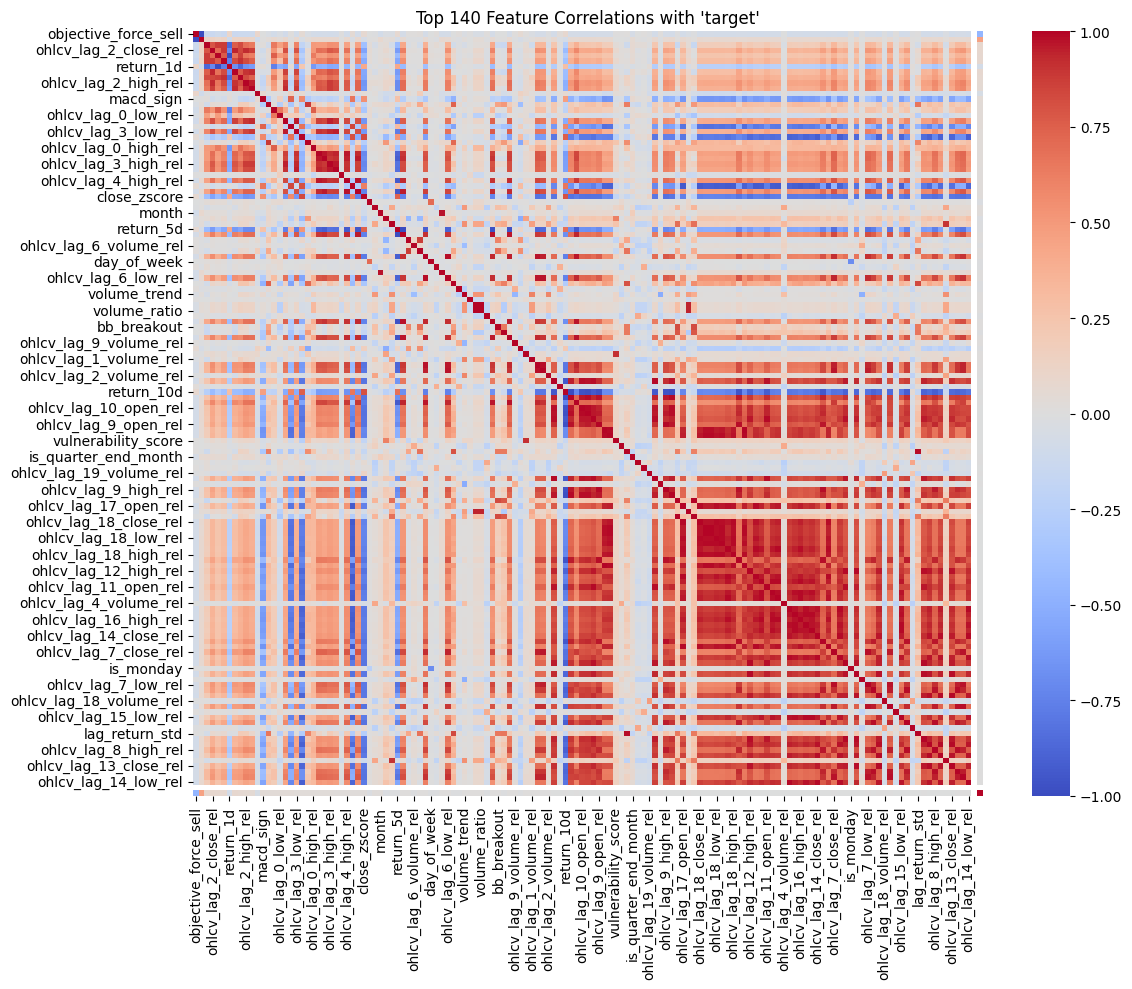


Top features correlated with target:

objective_force_sell     -0.453980
objective_force_buy       0.453980
ohlcv_lag_1_low_rel       0.081521
ohlcv_lag_2_close_rel     0.078858
ohlcv_lag_1_close_rel     0.072020
                            ...   
ohlcv_lag_13_close_rel   -0.000147
ohlcv_lag_8_close_rel     0.000066
ohlcv_lag_7_high_rel      0.000052
ohlcv_lag_14_low_rel      0.000011
ohlcv_lag_0_close_rel          NaN
Name: target, Length: 140, dtype: float64


,target
objective_force_sell,-0.453980
objective_force_buy,0.453980
ohlcv_lag_1_low_rel,0.081521
ohlcv_lag_2_close_rel,0.078858
ohlcv_lag_1_close_rel,0.072020
...,...
ohlcv_lag_13_close_rel,-0.000147
ohlcv_lag_8_close_rel,0.000066
ohlcv_lag_7_high_rel,0.000052
ohlcv_lag_14_low_rel,0.000011


In [8]:
df = pd.concat([X_train, y_train], axis=1)

feature_correlation_analysis(
    df,
    target_col="target",
    top_k=150,
)

## 5 · Train model

In [ ]:
# Chronological validation split
split_idx = int(len(X_train) * 0.8)
split_idx = min(max(split_idx, 1), len(X_train) - 1)
X_fit = X_train.iloc[:split_idx].copy()
y_fit = y_train.iloc[:split_idx].copy()
X_val = X_train.iloc[split_idx:].copy()
y_val = y_train.iloc[split_idx:].copy()

candidate_configs = [
    {"name": "gb_class_weight",    "model_type": "gradient_boosting", "imbalance_strategy": ImbalanceStrategy.CLASS_WEIGHT},
    {"name": "gb_smote_undersample","model_type": "gradient_boosting", "imbalance_strategy": ImbalanceStrategy.SMOTE_UNDERSAMPLE},
    {"name": "rf_class_weight",    "model_type": "random_forest",     "imbalance_strategy": ImbalanceStrategy.CLASS_WEIGHT},
    {"name": "logreg_class_weight","model_type": "logistic_regression","imbalance_strategy": ImbalanceStrategy.CLASS_WEIGHT},
]

In [12]:
print("Comparing candidate models...")

candidate_results = []
for cfg in candidate_configs:
    print(f"\nRunning {cfg['name']}...")
    pipeline = build_model(
        logger,
        model_type=cfg["model_type"],
        imbalance_strategy=cfg["imbalance_strategy"],
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_fit, y_fit, cv=cv, scoring="average_precision", n_jobs=-1)
    pipeline.fit(X_fit, y_fit)
    best_threshold, best_val_f1 = find_best_threshold(pipeline, X_val, y_val, logger, metric="f1")
    val_metrics = evaluate(pipeline, X_val, y_val, logger, threshold=best_threshold)
    candidate_results.append({
        "name":               cfg["name"],
        "model_type":         cfg["model_type"],
        "imbalance_strategy": cfg["imbalance_strategy"].value,
        "cv_pr_auc_mean":     float(cv_scores.mean()),
        "cv_pr_auc_std":      float(cv_scores.std()),
        "val_threshold":      float(best_threshold),
        "val_f1_attack":      float(val_metrics["f1_attack"]),
        "val_pr_auc":         float(val_metrics["pr_auc"]),
    })

results_df = (
    pd.DataFrame(candidate_results)
    .sort_values(["val_f1_attack", "val_pr_auc", "cv_pr_auc_mean"], ascending=False)
    .reset_index(drop=True)
)
results_df.to_csv(MODEL_COMPARISON_PATH, index=False)
print("\nCandidate summary:")
print(results_df.to_string(index=False))

best_row = results_df.iloc[0].to_dict()
print(f"\nBest config: {best_row['name']}")

best_pipeline = build_model(
    logger,
    model_type=best_row["model_type"],
    imbalance_strategy=ImbalanceStrategy(best_row["imbalance_strategy"]),
)
# Refit the selected model on the full loaded training split.
best_pipeline.fit(X_train, y_train)

metadata = {
    "model_type": best_row["model_type"],
    "imbalance_strategy": best_row["imbalance_strategy"],
    "threshold": float(best_row["val_threshold"]),
    "feature_columns": X_train.columns.tolist(),
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

save_model(best_pipeline, model_path, logger)

2026-06-24 15:21:25 [INFO] Built pipeline: model_type='gradient_boosting', imbalance_strategy='class_weight'.


Comparing candidate models...

Running gb_class_weight...


2026-06-24 15:29:44 [INFO] Best threshold (by f1): 0.05 → 0.5594
2026-06-24 15:29:44 [INFO] ── Evaluation (threshold=0.05) ──────────────────
2026-06-24 15:29:44 [INFO] Accuracy   : 0.7322  ← not reliable for imbalanced data
2026-06-24 15:29:44 [INFO] F1 (attack): 0.5594  ← primary metric
2026-06-24 15:29:44 [INFO] F1 (macro) : 0.6835
2026-06-24 15:29:44 [INFO] ROC-AUC    : 0.8364
2026-06-24 15:29:44 [INFO] PR-AUC     : 0.3950  ← best metric when attacks are rare
2026-06-24 15:29:44 [INFO] 
              precision    recall  f1-score   support

  non attack       1.00      0.68      0.81      1757
      attack       0.39      1.00      0.56       360

    accuracy                           0.73      2117
   macro avg       0.69      0.84      0.68      2117
weighted avg       0.90      0.73      0.77      2117

2026-06-24 15:29:44 [INFO] Built pipeline: model_type='gradient_boosting', imbalance_strategy='smote_undersample'.



Running gb_smote_undersample...


2026-06-24 15:48:07 [INFO] Best threshold (by f1): 0.10 → 0.5588
2026-06-24 15:48:07 [INFO] ── Evaluation (threshold=0.10) ──────────────────
2026-06-24 15:48:07 [INFO] Accuracy   : 0.7322  ← not reliable for imbalanced data
2026-06-24 15:48:07 [INFO] F1 (attack): 0.5588  ← primary metric
2026-06-24 15:48:07 [INFO] F1 (macro) : 0.6832
2026-06-24 15:48:07 [INFO] ROC-AUC    : 0.8466
2026-06-24 15:48:07 [INFO] PR-AUC     : 0.4125  ← best metric when attacks are rare
2026-06-24 15:48:07 [INFO] 
              precision    recall  f1-score   support

  non attack       1.00      0.68      0.81      1757
      attack       0.39      1.00      0.56       360

    accuracy                           0.73      2117
   macro avg       0.69      0.84      0.68      2117
weighted avg       0.90      0.73      0.77      2117

2026-06-24 15:48:07 [INFO] Built pipeline: model_type='random_forest', imbalance_strategy='class_weight'.


...

2026-06-24 15:49:08 [INFO] Best threshold (by f1): 0.25 → 0.5599
2026-06-24 15:49:08 [INFO] ── Evaluation (threshold=0.25) ──────────────────
2026-06-24 15:49:08 [INFO] Accuracy   : 0.7326  ← not reliable for imbalanced data
2026-06-24 15:49:08 [INFO] F1 (attack): 0.5599  ← primary metric
2026-06-24 15:49:08 [INFO] F1 (macro) : 0.6839
2026-06-24 15:49:08 [INFO] ROC-AUC    : 0.8436
2026-06-24 15:49:08 [INFO] PR-AUC     : 0.4049  ← best metric when attacks are rare
2026-06-24 15:49:08 [INFO] 
              precision    recall  f1-score   support

  non attack       1.00      0.68      0.81      1757
      attack       0.39      1.00      0.56       360

    accuracy                           0.73      2117
   macro avg       0.69      0.84      0.68      2117
weighted avg       0.90      0.73      0.77      2117

2026-06-24 15:49:08 [INFO] Built pipeline: model_type='logistic_regression', imbalance_strategy='class_weight'.



Running logreg_class_weight...


2026-06-24 15:49:12 [INFO] Best threshold (by f1): 0.35 → 0.5587
2026-06-24 15:49:12 [INFO] ── Evaluation (threshold=0.35) ──────────────────
2026-06-24 15:49:12 [INFO] Accuracy   : 0.7336  ← not reliable for imbalanced data
2026-06-24 15:49:12 [INFO] F1 (attack): 0.5587  ← primary metric
2026-06-24 15:49:12 [INFO] F1 (macro) : 0.6839
2026-06-24 15:49:12 [INFO] ROC-AUC    : 0.8461
2026-06-24 15:49:12 [INFO] PR-AUC     : 0.4167  ← best metric when attacks are rare
2026-06-24 15:49:12 [INFO] 
              precision    recall  f1-score   support

  non attack       1.00      0.68      0.81      1757
      attack       0.39      0.99      0.56       360

    accuracy                           0.73      2117
   macro avg       0.69      0.84      0.68      2117
weighted avg       0.89      0.73      0.77      2117

2026-06-24 15:49:12 [INFO] Built pipeline: model_type='random_forest', imbalance_strategy='class_weight'.



Candidate summary:
                name          model_type imbalance_strategy  cv_pr_auc_mean  cv_pr_auc_std  val_threshold  val_f1_attack  val_pr_auc
     rf_class_weight       random_forest       class_weight        0.433766       0.012218           0.25       0.559876    0.404900
     gb_class_weight   gradient_boosting       class_weight        0.447235       0.019135           0.05       0.559441    0.395038
gb_smote_undersample   gradient_boosting  smote_undersample        0.440487       0.015725           0.10       0.558755    0.412510
 logreg_class_weight logistic_regression       class_weight        0.383419       0.023338           0.35       0.558685    0.416706

Best config: rf_class_weight


2026-06-24 15:49:28 [INFO] Model saved to '/content/drive/MyDrive/master-thesis/notebooks/models/attack_day/attack_day.pkl'.


## 6 · Evaluate model

In [13]:
bundle = load_attack_model(model_path, meta_path, logger)

model = bundle["model"]
threshold = bundle["threshold"]

results      = predict(model, X_test, threshold)
test_metrics = evaluate(model, X_test, y_test, logger, threshold)

print("\nTest metrics:")
print(pd.Series(test_metrics).drop(labels=["classification_report", "confusion_matrix"]).to_string())

2026-06-24 15:51:47 [INFO] Model loaded from '/content/drive/MyDrive/master-thesis/notebooks/models/attack_day/attack_day.pkl'.
2026-06-24 15:51:48 [INFO] ── Evaluation (threshold=0.25) ──────────────────
2026-06-24 15:51:48 [INFO] Accuracy   : 0.8032  ← not reliable for imbalanced data
2026-06-24 15:51:48 [INFO] F1 (attack): 0.5207  ← primary metric
2026-06-24 15:51:48 [INFO] F1 (macro) : 0.6984
2026-06-24 15:51:48 [INFO] ROC-AUC    : 0.8966
2026-06-24 15:51:48 [INFO] PR-AUC     : 0.3774  ← best metric when attacks are rare
2026-06-24 15:51:48 [INFO] 
              precision    recall  f1-score   support

  non attack       1.00      0.78      0.88      2364
      attack       0.35      1.00      0.52       283

    accuracy                           0.80      2647
   macro avg       0.68      0.89      0.70      2647
weighted avg       0.93      0.80      0.84      2647




Test metrics:
accuracy     0.803173
f1_attack    0.520699
f1_macro     0.698429
roc_auc      0.896646
pr_auc        0.37744
threshold        0.25


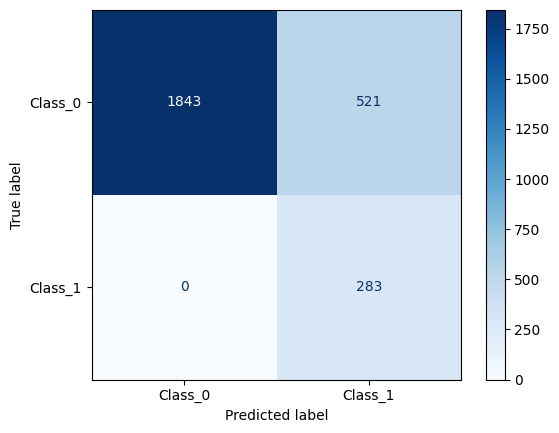

[[1843  521]
 [   0  283]]
              precision    recall  f1-score   support

           0       1.00      0.78      0.88      2364
           1       0.35      1.00      0.52       283

    accuracy                           0.80      2647
   macro avg       0.68      0.89      0.70      2647
weighted avg       0.93      0.80      0.84      2647

ROC-AUC : 0.8966
PR-AUC  : 0.3774


In [14]:
cm = confusion_matrix(y_test, results.prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class_0", "Class_1"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

print(cm)
print(classification_report(y_test, results.prediction))
print(f"ROC-AUC : {roc_auc_score(y_test, results.probability):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, results.probability):.4f}")

In [19]:
# FEATURE IMPORTANCE
fi = feature_importance(
    model,
    feature_names=bundle["feature_columns"],
    top_n=20,
)

print(fi.to_string(index=False))

              feature  importance
  objective_force_buy    0.341378
 objective_force_sell    0.292266
                 macd    0.009106
               atr_14    0.007624
  lag_return_autocorr    0.006762
        hl_range_mean    0.006717
ohlcv_lag_2_close_rel    0.006616
  ohlcv_lag_1_low_rel    0.006564
 ohlcv_lag_1_open_rel    0.005844
    rsi_neutral_x_atr    0.005826
         bb_atr_ratio    0.005621
       volatility_20d    0.005605
       lag_return_std    0.005097
  ohlcv_lag_2_low_rel    0.004753
ohlcv_lag_1_close_rel    0.004673
       trend_strength    0.004556
   bollinger_width_20    0.004138
            return_1d    0.004023
 ohlcv_lag_2_high_rel    0.003926
 ohlcv_lag_2_open_rel    0.003642
